# Baseline

Full-order neural-network policy trained on full-order dynamics.

- **Policy**: MLP with two hidden layers of 64 units each (`NET_ARCH = [64, 64]`), mapping the 9-dim observation directly to a single cart-force command. No model structure assumed.
- **Dynamics**: Trained entirely inside the MuJoCo rigid-body simulation — full nonlinear physics. The policy never sees a reduced or linearised model.
- **Observation**: 9 dimensions: `x_cart`, `sin(θ₁)`, `sin(θ₂)`, `cos(θ₁)`, `cos(θ₂)`, `ẋ`, `θ̇₁`, `θ̇₂`, `constraint_force`. Nothing is discarded.


In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from tqdm.auto import tqdm
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, CheckpointCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy

# import custom plotting helper functions
sys.path.insert(0, "../src")
from plotting_utils import (
    plot_network_diagram,
    plot_training_results,
    plot_rollout_trajectory,
    render_episode,
)

# ── Config ─────────────────────────────────────────────────────────────────────
ENV_ID          = "InvertedDoublePendulum-v5"
TOTAL_STEPS     = 400_000
N_ENVS          = 8
N_EVAL_ENVS     = 4
N_STEPS         = 2048
BATCH_SIZE      = 64
ENT_COEF        = 0.001
GAMMA           = 0.99
LEARNING_RATE   = 3e-4
NET_ARCH        = [64, 64]
N_EVAL_EPISODES = 20
EVAL_FREQ       = max(1, 25_000 // N_ENVS)
CHECKPOINT_DIR  = "../data/baseline/checkpoints"
MODEL_PATH      = "../data/baseline/checkpoints/ppo_double_pendulum"

STATE_LABELS     = ["x", "θ₁", "θ₂", "ẋ", "θ̇₁", "θ̇₂"]
NET_INPUT_LABELS = [
    r"$x$",
    r"$\sin\theta_1$", r"$\sin\theta_2$",
    r"$\cos\theta_1$", r"$\cos\theta_2$",
    r"$\dot{x}$",
    r"$\dot{\theta}_1$", r"$\dot{\theta}_2$",
    r"$f_c$",
]

_env      = gym.make(ENV_ID)
MAX_STEPS = _env.spec.max_episode_steps
DT        = _env.unwrapped.dt
OBS_DIM   = _env.observation_space.shape[0]
ACT_DIM   = _env.action_space.shape[0]
_env.close()

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"MAX_STEPS = {MAX_STEPS}  |  DT = {DT} s  |  OBS_DIM = {OBS_DIM}  |  ACT_DIM = {ACT_DIM}")

MAX_STEPS = 1000  |  DT = 0.05 s  |  OBS_DIM = 9  |  ACT_DIM = 1


**Helper** functions

In [2]:
# map 9-dim from simulation to the 6 physical dims
def obs_to_state6(obs):
    """9-dim MuJoCo observation → 6-dim state [x, θ₁, θ₂, ẋ, θ̇₁, θ̇₂]."""
    return np.array([
        obs[0],
        np.arctan2(obs[1], obs[3]),
        np.arctan2(obs[2], obs[4]),
        obs[5], obs[6], obs[7],
    ], dtype=np.float64)


---

## Policy Network Architecture

**Parameter Count**

In [3]:
import torch
import torch.nn as nn
from torchinfo import summary


# SB3 PPO needs two separate networks during training: the actor (produces the
# action distribution) and the critic (estimates V(s) — expected discounted
# future return — for advantage computation). At inference only the actor path
# is used (policy_trunk + action_head), which is what the diagram visualises.
class ActorCriticMLP(nn.Module):
    def __init__(self, obs_dim, net_arch, act_dim):
        super().__init__()
        self.policy_trunk = self._trunk(obs_dim, net_arch)
        self.value_trunk  = self._trunk(obs_dim, net_arch)
        self.action_head  = nn.Linear(net_arch[-1], act_dim)
        self.value_head   = nn.Linear(net_arch[-1], 1)
        self.log_std      = nn.Parameter(torch.zeros(act_dim))

    @staticmethod
    def _trunk(in_dim, hidden_dims):
        layers, dims = [], [in_dim] + hidden_dims
        for i in range(len(dims) - 1):
            layers += [nn.Linear(dims[i], dims[i + 1]), nn.Tanh()]
        return nn.Sequential(*layers)

    def forward(self, obs):
        return (self.action_head(self.policy_trunk(obs)),
                self.value_head(self.value_trunk(obs)))

# determine the number of trainable parameters
summary(
    ActorCriticMLP(OBS_DIM, NET_ARCH, ACT_DIM),
    input_size=(1, OBS_DIM),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=18,
    depth=3,
    verbose=1,
);

Layer (type:depth-idx)                   Input Shape        Output Shape       Param #            Trainable
ActorCriticMLP                           [1, 9]             [1, 1]             1                  True
├─Sequential: 1-1                        [1, 9]             [1, 64]            --                 True
│    └─Linear: 2-1                       [1, 9]             [1, 64]            640                True
│    └─Tanh: 2-2                         [1, 64]            [1, 64]            --                 --
│    └─Linear: 2-3                       [1, 64]            [1, 64]            4,160              True
│    └─Tanh: 2-4                         [1, 64]            [1, 64]            --                 --
├─Linear: 1-2                            [1, 64]            [1, 1]             65                 True
├─Sequential: 1-3                        [1, 9]             [1, 64]            --                 True
│    └─Linear: 2-5                       [1, 9]             [1, 64]     

**PPO Inference Architecture**

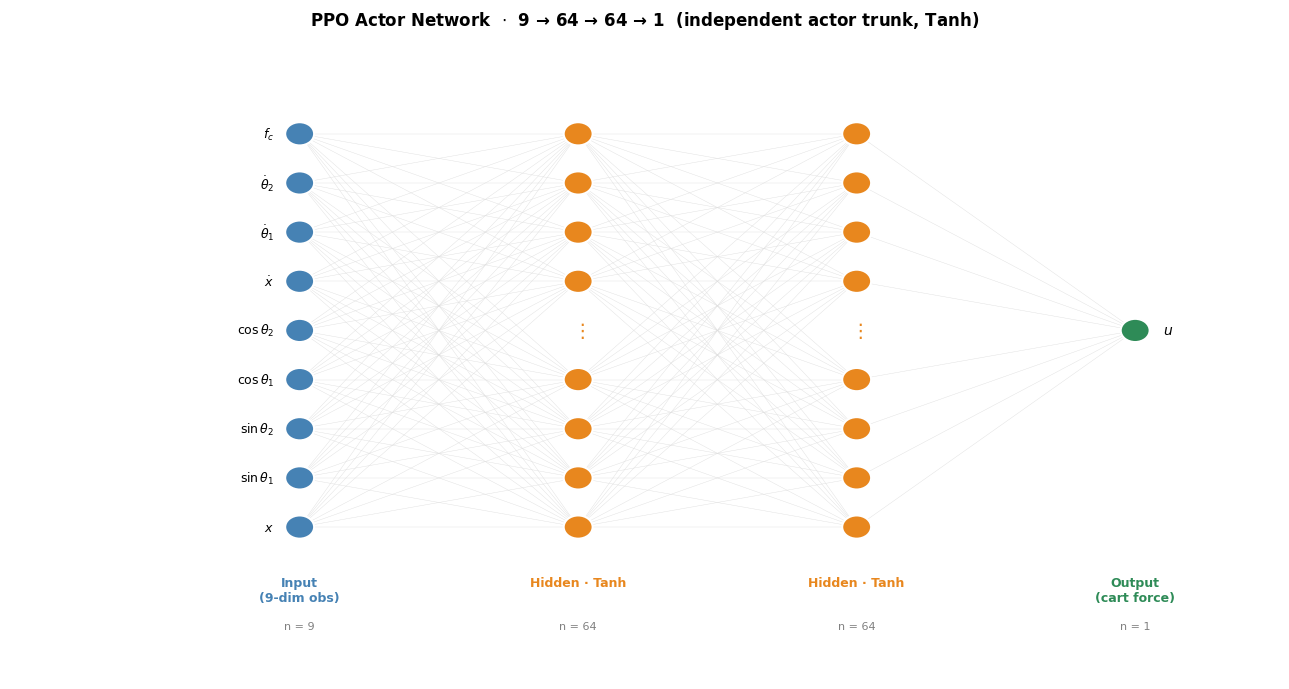

In [4]:
arch        = [OBS_DIM] + NET_ARCH + [ACT_DIM]
hidden_names = [f"Hidden · Tanh" for _ in NET_ARCH]
layer_names  = [f"Input\n({OBS_DIM}-dim obs)"] + hidden_names + ["Output\n(cart force)"]

plot_network_diagram(
    arch=arch,
    layer_names=layer_names,
    input_labels=NET_INPUT_LABELS,
    title=r"PPO Actor Network  $\cdot$  " + " → ".join(str(w) for w in arch)
          + r"  (independent actor trunk, Tanh)",
)

---

## Training

PPO runs in `N_ENVS` parallel environments. `EvalCallback` periodically evaluates the policy and saves the best checkpoint. No behavioural cloning or reward curriculum needed — `InvertedDoublePendulum-v5` has a dense, well-shaped reward from the start.

In [5]:
class _TqdmCallback(BaseCallback):
    """tqdm progress bar + in-memory training history (no table output)."""

    def __init__(self, total_steps: int):
        super().__init__(verbose=0)
        self._pbar = tqdm(total=total_steps, unit="step", desc="PPO")
        self.history: dict = {"timesteps": [], "ep_len": [], "ep_rew": []}

    def _on_step(self) -> bool:
        return True

    def _on_rollout_end(self) -> None:
        self._pbar.n = self.num_timesteps
        if self.model.ep_info_buffer:
            ep_len = np.mean([ep["l"] for ep in self.model.ep_info_buffer])
            ep_rew = np.mean([ep["r"] for ep in self.model.ep_info_buffer])
            self._pbar.set_postfix(ep_len=f"{ep_len:.0f}", ep_rew=f"{ep_rew:.1f}", refresh=False)
            self.history["timesteps"].append(self.num_timesteps)
            self.history["ep_len"].append(float(ep_len))
            self.history["ep_rew"].append(float(ep_rew))
        self._pbar.refresh()

    def _on_training_end(self) -> None:
        self._pbar.n = self._pbar.total
        self._pbar.refresh()
        self._pbar.close()


vec_env = make_vec_env(ENV_ID, n_envs=N_ENVS)

eval_env = make_vec_env(ENV_ID, n_envs=N_EVAL_ENVS)
eval_cb = EvalCallback(
    eval_env,
    best_model_save_path=CHECKPOINT_DIR,
    log_path=CHECKPOINT_DIR,
    eval_freq=EVAL_FREQ,
    n_eval_episodes=N_EVAL_EPISODES,
    deterministic=True,
    verbose=0,
)

checkpoint_cb = CheckpointCallback(
    save_freq=max(1, 200_000 // N_ENVS),
    save_path=CHECKPOINT_DIR,
    name_prefix="ckpt",
    verbose=0,
)

tqdm_cb = _TqdmCallback(TOTAL_STEPS)

model = PPO(
    "MlpPolicy",
    vec_env,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    ent_coef=ENT_COEF,
    gamma=GAMMA,
    learning_rate=LEARNING_RATE,
    policy_kwargs=dict(net_arch=NET_ARCH),
    verbose=0,
)

model.learn(total_timesteps=TOTAL_STEPS, callback=[eval_cb, checkpoint_cb, tqdm_cb])
model.save(MODEL_PATH)
vec_env.close()
eval_env.close()
print(f"Done — final ep_len {tqdm_cb.history['ep_len'][-1]:.0f} / {MAX_STEPS}")

PPO:   0%|          | 0/400000 [00:00<?, ?step/s]

Done — final ep_len 8 / 1000


**Evaluate** the best performing policy

Evaluating: ../data/baseline/checkpoints/best_model.zip
Mean length : 1000.0 / 1000 steps (50.0 s)
Mean reward : 9345.83 +/- 0.24
Survival >50%: 100%
Perfect (=1000): 100%


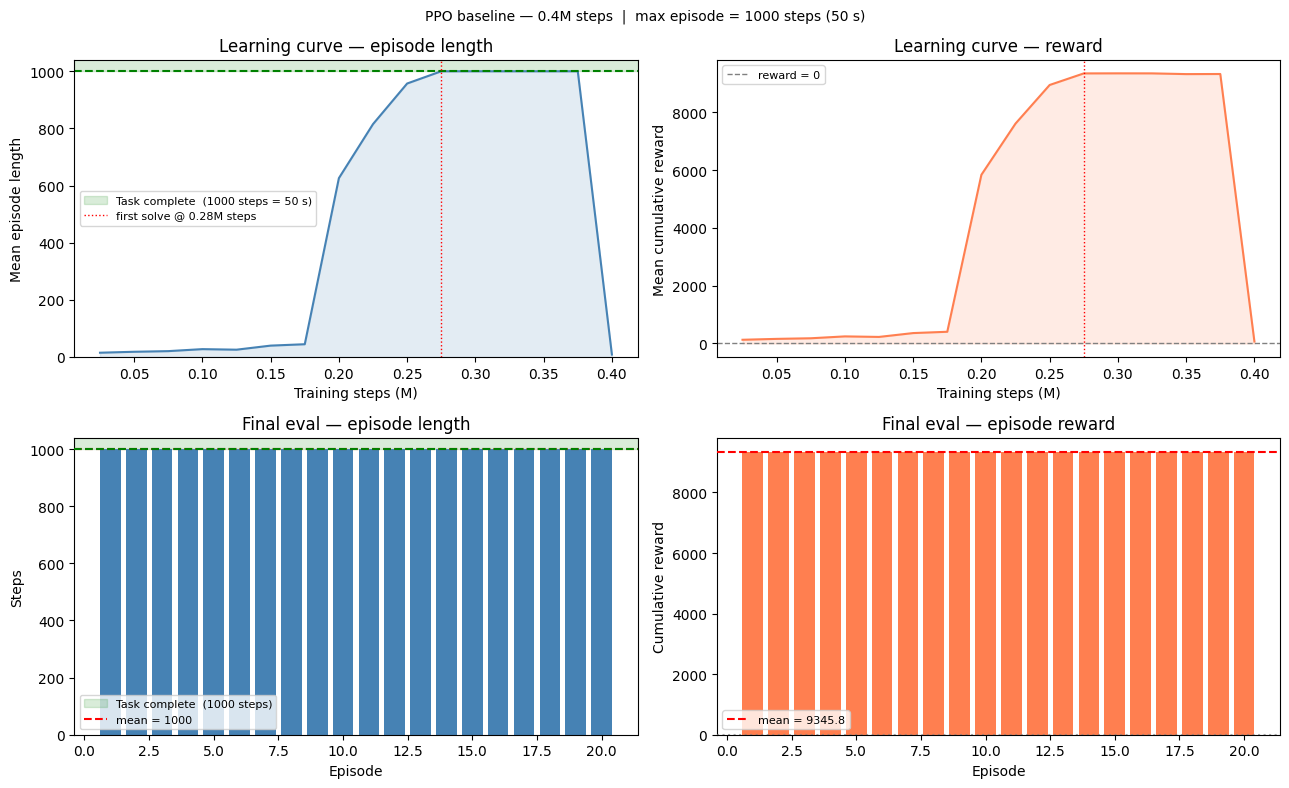

In [6]:
best       = os.path.join(CHECKPOINT_DIR, "best_model.zip")
model_path = best if os.path.exists(best) else MODEL_PATH + ".zip"

eval_env = make_vec_env(ENV_ID, n_envs=N_EVAL_ENVS)
model    = PPO.load(model_path, env=eval_env)
print(f"Evaluating: {model_path}")

ep_rewards, ep_lengths = evaluate_policy(
    model, eval_env,
    n_eval_episodes=N_EVAL_EPISODES,
    return_episode_rewards=True,
    deterministic=True,
)
eval_env.close()

print(f"Mean length : {np.mean(ep_lengths):.1f} / {MAX_STEPS} steps ({np.mean(ep_lengths)*DT:.1f} s)")
print(f"Mean reward : {np.mean(ep_rewards):.2f} +/- {np.std(ep_rewards):.2f}")
print(f"Survival >50%: {100*np.mean(np.array(ep_lengths)>MAX_STEPS//2):.0f}%")
print(f"Perfect (={MAX_STEPS}): {100*np.mean(np.array(ep_lengths)==MAX_STEPS):.0f}%")

evals = np.load(os.path.join(CHECKPOINT_DIR, "evaluations.npz"))
plot_training_results(
    ep_lengths, ep_rewards,
    evals["timesteps"] / 1e6,
    evals["ep_lengths"].mean(axis=1),
    evals["results"].mean(axis=1),
    total_steps=TOTAL_STEPS,
    max_steps=MAX_STEPS,
    dt=DT,
    title=f"PPO baseline — {TOTAL_STEPS/1e6:.1f}M steps  |  max episode = {MAX_STEPS} steps ({MAX_STEPS*DT:.0f} s)",
)

**Observations**

- **100% task success.** All 20 evaluation episodes ran the full 1000 steps (50 s). The near-zero standard deviation on reward shows the policy is essentially deterministic and highly repeatable across seeds.

- **Near-maximum reward per step.** The theoretical maximum is 10/step (alive bonus, no penalties). The combined distance and velocity penalty averaged less than 1/step — both poles were kept nearly upright for the entire episode.

- **Fast convergence.** The dense reward (non-zero from step 1) meant there was no cold-start problem. The best checkpoint was saved well before the 400k-step budget ended.

- **Cart position is not a hard termination condition.** The 0.2 m figure in the reward formula (`dist_penalty`) affects the reward continuously but does not terminate the episode — the only hard termination is tip height ≤ 1 m. The policy accepted some cart drift to maintain both poles upright; correcting this would require adding an explicit cart position constraint to the reward.

- **Tiny network is sufficient.** 9,731 parameters (~0.04 MB) solves the task perfectly. The 9-dim observation is low-dimensional and the reward is well-shaped, so a [64, 64] MLP is not a bottleneck. This is the performance ceiling for Track B — all SINDy-based policies will be compared against it.

---

## Transition Data Collection

Roll out the trained policy to collect `(X, U, X_next)` transition tuples in the
6-dim physical state space `[x, θ₁, θ₂, ẋ, θ̇₁, θ̇₂]`. Saved to
`data/baseline/trajectories_baseline.npz` for use by Track A (SINDy dynamics) and
Track B (sparse SINDy policy).

The stochastic policy (`deterministic=False`) is used so each episode follows a
slightly different near-equilibrium trajectory, giving broader state-space
coverage than a single deterministic rollout.

In [7]:
import pathlib

N_COLLECT_STEPS = 50_000
DATA_PATH       = pathlib.Path("../data/baseline/trajectories_baseline.npz")
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

best       = os.path.join(CHECKPOINT_DIR, "best_model.zip")
model_path = best if os.path.exists(best) else MODEL_PATH + ".zip"
model      = PPO.load(model_path)

collect_env = gym.make(ENV_ID)
X, U, X_next = [], [], []
total = 0

while total < N_COLLECT_STEPS:
    obs, _ = collect_env.reset()
    done   = False
    while not done and total < N_COLLECT_STEPS:
        s         = obs_to_state6(obs)
        action, _ = model.predict(obs, deterministic=False)
        obs_next, _, terminated, truncated, _ = collect_env.step(action)
        done   = terminated or truncated
        X.append(s)
        U.append(action.astype(np.float64))
        X_next.append(obs_to_state6(obs_next))
        obs    = obs_next
        total += 1

collect_env.close()

X      = np.array(X)
U      = np.array(U)
X_next = np.array(X_next)

np.savez_compressed(DATA_PATH, X=X, U=U, X_next=X_next)

print(f"Saved → {DATA_PATH}")
print(f"  X      : {X.shape}   (state at step k)")
print(f"  U      : {U.shape}   (action at step k)")
print(f"  X_next : {X_next.shape}   (state at step k+1)")
print(f"\nState ranges:")
for i, label in enumerate(STATE_LABELS):
    print(f"  {label:6s}  [{X[:, i].min():+.4f}, {X[:, i].max():+.4f}]")

Saved → ../data/baseline/trajectories_baseline.npz
  X      : (50000, 6)   (state at step k)
  U      : (50000, 1)   (action at step k)
  X_next : (50000, 6)   (state at step k+1)

State ranges:
  x       [-1.0070, +1.0221]
  θ₁      [-0.8262, +0.7923]
  θ₂      [-1.0437, +1.0670]
  ẋ       [-6.3462, +6.4274]
  θ̇₁     [-6.3717, +7.0812]
  θ̇₂     [-9.8607, +9.0900]


---

## Policy Rollout — State Trajectories

Roll out one deterministic episode with the trained policy and record the full state trajectory. Plots confirm the policy simultaneously controls cart position and keeps both poles upright across the entire 50-second window.

Episode  : 1000 / 1000 steps  (50.0 s)  ← TASK COMPLETE
Mean r   : 9.3470   cumulative: 9347.00
Cart pos : max |x| = 0.6160 m  (limit 0.2 m)


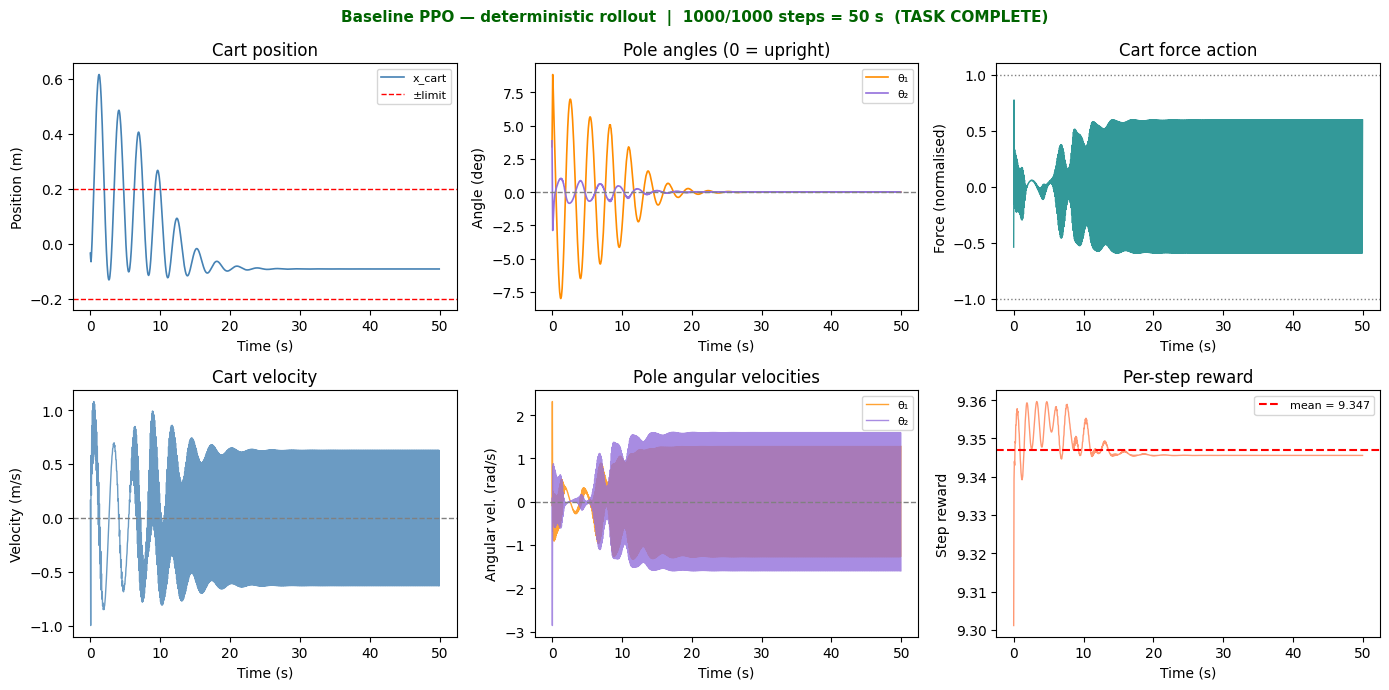

In [8]:
best       = os.path.join(CHECKPOINT_DIR, "best_model.zip")
model_path = best if os.path.exists(best) else MODEL_PATH + ".zip"

rollout_env = gym.make(ENV_ID)
model       = PPO.load(model_path)
obs, _      = rollout_env.reset()

states_6, actions, rewards = [], [], []
done = truncated = False
while not (done or truncated):
    action, _ = model.predict(obs, deterministic=True)
    states_6.append(obs_to_state6(obs))
    obs, r, done, truncated, _ = rollout_env.step(action)
    actions.append(float(action[0]))
    rewards.append(r)
rollout_env.close()

states_6 = np.array(states_6)
actions  = np.array(actions)
rewards  = np.array(rewards)

n_steps = len(actions)
status  = "TASK COMPLETE" if n_steps >= MAX_STEPS else "FAILED"
print(f"Episode  : {n_steps} / {MAX_STEPS} steps  ({n_steps * DT:.1f} s)  ← {status}")
print(f"Mean r   : {np.mean(rewards):.4f}   cumulative: {rewards.sum():.2f}")
print(f"Cart pos : max |x| = {np.abs(states_6[:, 0]).max():.4f} m  (limit 0.2 m)")

plot_rollout_trajectory(
    states_6, actions, rewards, DT,
    title="Baseline PPO — deterministic rollout",
    max_steps=MAX_STEPS,
)

---

## Policy Visualization

One rendered episode captured as an animation (4× speed). Visually confirms both poles remain upright and the cart stays within bounds for the full 50-second window.

In [9]:
best       = os.path.join(CHECKPOINT_DIR, "best_model.zip")
model_path = best if os.path.exists(best) else MODEL_PATH + ".zip"
model      = PPO.load(model_path)

render_episode(
    lambda obs: model.predict(obs, deterministic=True)[0],
    ENV_ID, MAX_STEPS, DT,
    title="PPO baseline",
    seed=0,
)

1000 / 1000 steps  (50.0 s)  ← TASK COMPLETE
